In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings('ignore')

In [82]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [83]:
print("Shape:", df.shape)
print()
df.info()

Shape: (768, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [84]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [85]:
print("Missing Values:")
print(df.isnull().sum())
print()
print("Jumlah Duplikat:", df.duplicated().sum())

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Jumlah Duplikat: 0


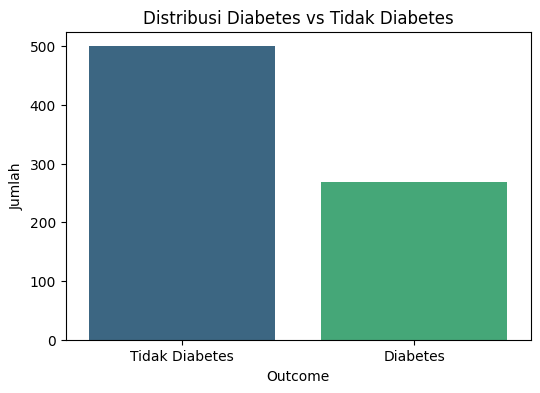

Distribusi Target:
Outcome
0    500
1    268
Name: count, dtype: int64

Persentase:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [86]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Distribusi Diabetes vs Tidak Diabetes')
plt.xticks([0, 1], ['Tidak Diabetes', 'Diabetes'])
plt.ylabel('Jumlah')
plt.show()

print("Distribusi Target:")
print(df['Outcome'].value_counts())
print()
print("Persentase:")
print(df['Outcome'].value_counts(normalize=True) * 100)

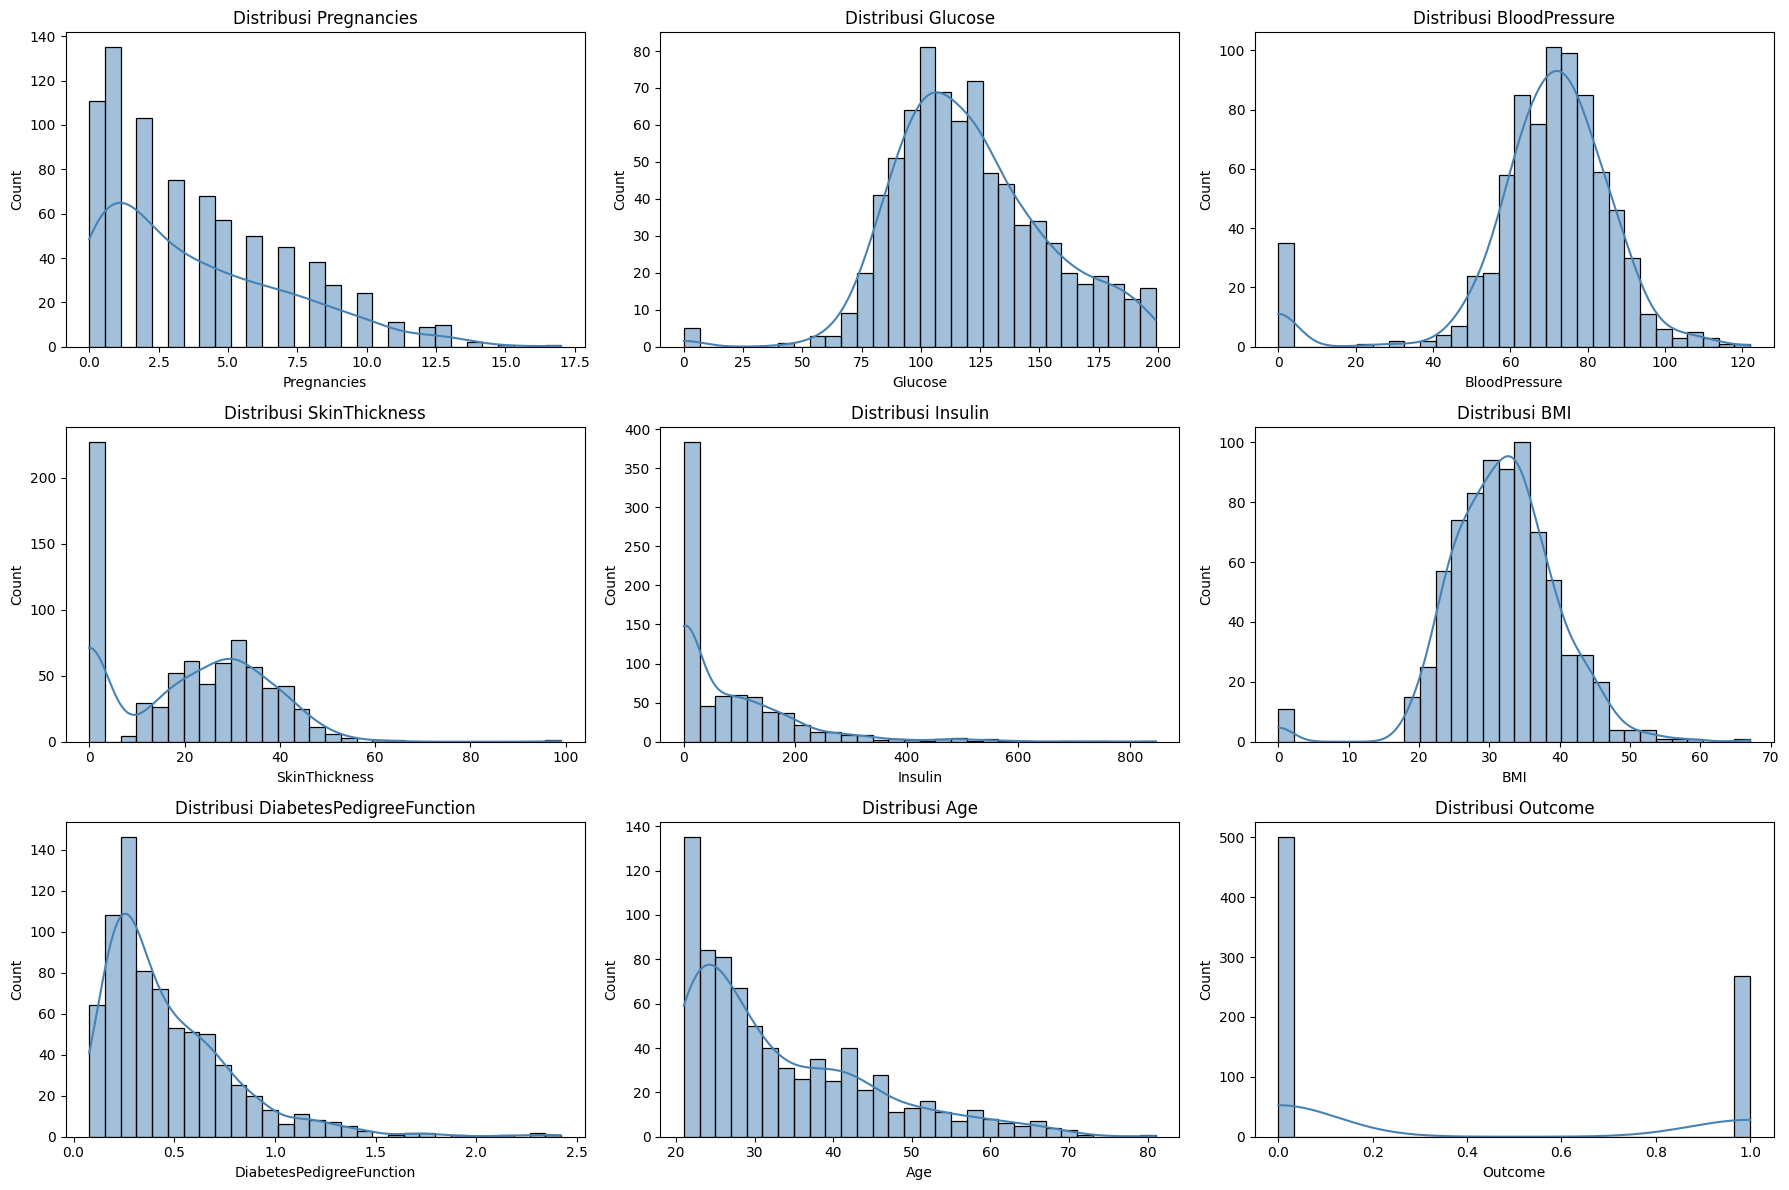

In [87]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

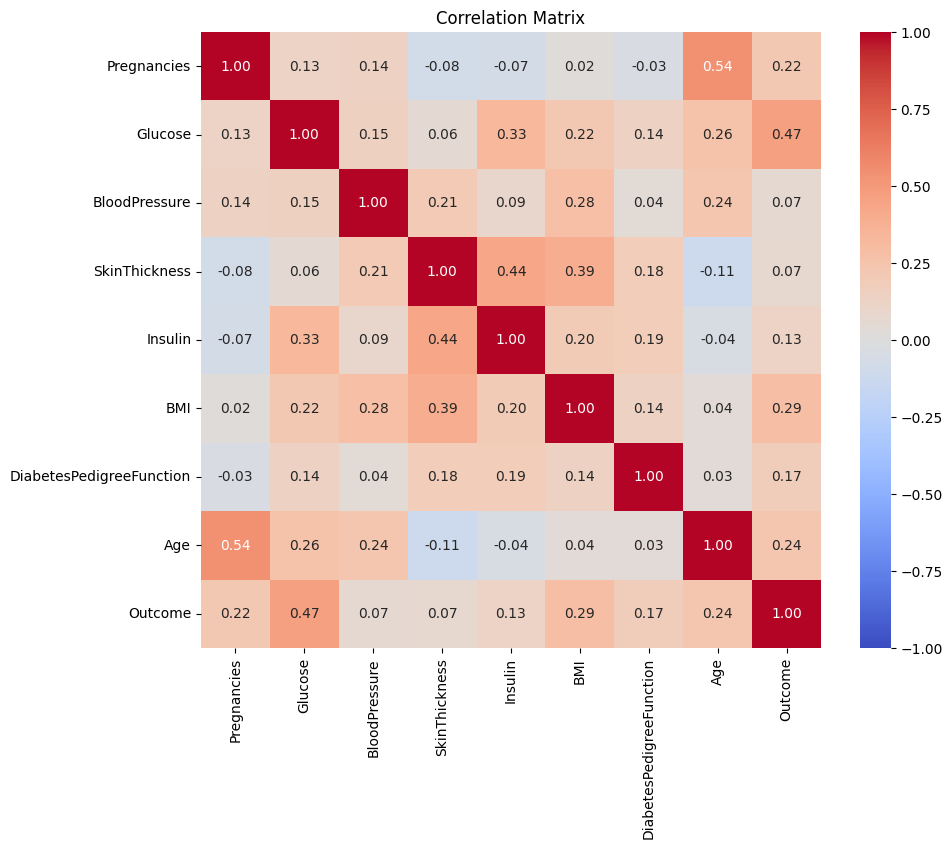

In [88]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

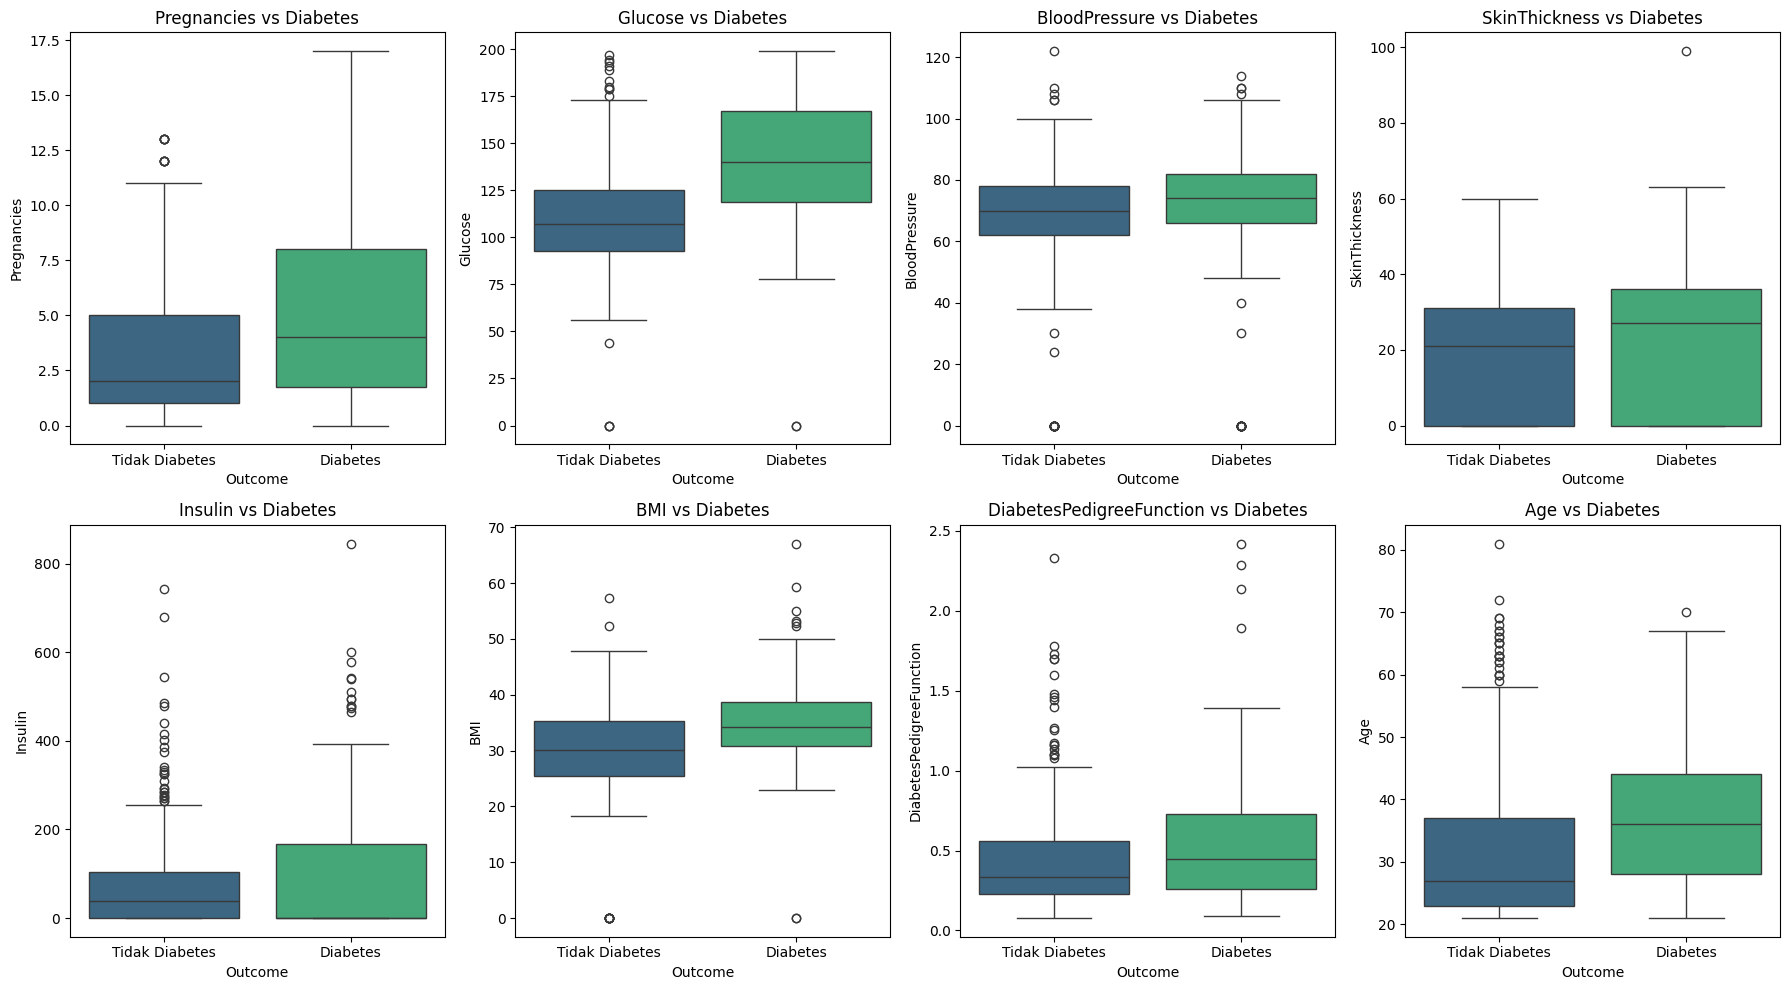

In [89]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for i, col in enumerate(features):
    sns.boxplot(x='Outcome', y=col, data=df, palette='viridis', ax=axes[i])
    axes[i].set_title(f'{col} vs Diabetes')
    axes[i].set_xticklabels(['Tidak Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

In [90]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Jumlah nilai 0 per kolom:")
for col in cols_with_zeros:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"  {col}: {zeros} ({pct:.1f}%)")

Jumlah nilai 0 per kolom:
  Glucose: 5 (0.7%)
  BloodPressure: 35 (4.6%)
  SkinThickness: 227 (29.6%)
  Insulin: 374 (48.7%)
  BMI: 11 (1.4%)


In [91]:
for col in cols_with_zeros:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)

print("✅ Hidden missing values berhasil ditangani!")
print()
print("Cek nilai 0 setelah penanganan:")
for col in cols_with_zeros:
    zeros = (df[col] == 0).sum()
    print(f"  {col}: {zeros}")

✅ Hidden missing values berhasil ditangani!

Cek nilai 0 setelah penanganan:
  Glucose: 0
  BloodPressure: 0
  SkinThickness: 0
  Insulin: 0
  BMI: 0


In [92]:
scaler = StandardScaler()

feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

df[feature_cols] = scaler.fit_transform(df[feature_cols])

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.866045,-0.031990,0.831114,-0.608201,0.167240,0.468492,1.425995,1
1,-0.844885,-1.205066,-0.528319,0.180566,-0.608201,-0.851551,-0.365061,-0.190672,0
2,1.233880,2.016662,-0.693761,-0.469981,-0.608201,-1.331838,0.604397,-0.105584,1
3,-0.844885,-1.073567,-0.528319,-0.469981,-0.006185,-0.633239,-0.920763,-1.041549,0
4,-1.141852,0.504422,-2.679076,0.831114,0.695378,1.549885,5.484909,-0.020496,1


In [93]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data total :", len(X))
print("Jumlah data latih :", len(X_train))
print("Jumlah data test  :", len(X_test))

Jumlah data total : 768
Jumlah data latih : 614
Jumlah data test  : 154


In [94]:
#Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("=" * 50)
print("DECISION TREE")
print("=" * 50)
print(classification_report(y_test, y_pred_dt))

DECISION TREE
              precision    recall  f1-score   support

           0       0.72      0.79      0.76       100
           1       0.53      0.44      0.48        54

    accuracy                           0.67       154
   macro avg       0.63      0.62      0.62       154
weighted avg       0.66      0.67      0.66       154



In [95]:
#Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



In [96]:
#Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [97]:
#Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("=" * 50)
print("GRADIENT BOOSTING")
print("=" * 50)
print(classification_report(y_test, y_pred_gb))

GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



In [98]:
#Perbandingan Semua Model
print("=" * 60)
print("PERBANDINGAN SEMUA MODEL")
print("=" * 60)

all_models = {
    'Decision Tree'      : y_pred_dt,
    'Random Forest'      : y_pred_rf,
    'Logistic Regression': y_pred_lr,
    'Gradient Boosting'  : y_pred_gb
}

for name, y_pred in all_models.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    print(f"{name}:")
    print(f"  Accuracy  : {report['accuracy']:.4f}")
    print(f"  Precision : {report['weighted avg']['precision']:.4f}")
    print(f"  Recall    : {report['weighted avg']['recall']:.4f}")
    print(f"  F1-Score  : {report['weighted avg']['f1-score']:.4f}")
    print()

PERBANDINGAN SEMUA MODEL
Decision Tree:
  Accuracy  : 0.6688
  Precision : 0.6576
  Recall    : 0.6688
  F1-Score  : 0.6609

Random Forest:
  Accuracy  : 0.7597
  Precision : 0.7546
  Recall    : 0.7597
  F1-Score  : 0.7555

Logistic Regression:
  Accuracy  : 0.7078
  Precision : 0.6989
  Recall    : 0.7078
  F1-Score  : 0.7008

Gradient Boosting:
  Accuracy  : 0.7597
  Precision : 0.7546
  Recall    : 0.7597
  F1-Score  : 0.7555



In [99]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Distribusi sebelum SMOTE:")
print(y_train.value_counts())
print()
print("Distribusi setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Distribusi sebelum SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64

Distribusi setelah SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64


In [100]:
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test)

print("=" * 50)
print("RANDOM FOREST + SMOTE")
print("=" * 50)
print(classification_report(y_test, y_pred_rf_smote))

RANDOM FOREST + SMOTE
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [101]:
params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_tuned = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train_smote, y_train_smote)

print("Best Parameters:", rf_tuned.best_params_)
print("Best Score     :", rf_tuned.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Score     : 0.8241144268381545


In [102]:
# Cell 23 - Evaluasi Model Tuned
y_pred_tuned = rf_tuned.predict(X_test)

print("=" * 50)
print("RANDOM FOREST + SMOTE + TUNING")
print("=" * 50)
print(classification_report(y_test, y_pred_tuned))

RANDOM FOREST + SMOTE + TUNING
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



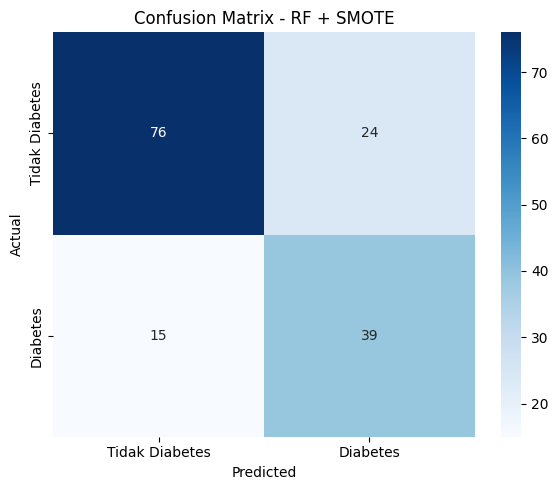

In [103]:
#Confusion Matrix Model Terbaik
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf_smote)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Diabetes', 'Diabetes'],
            yticklabels=['Tidak Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - RF + SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

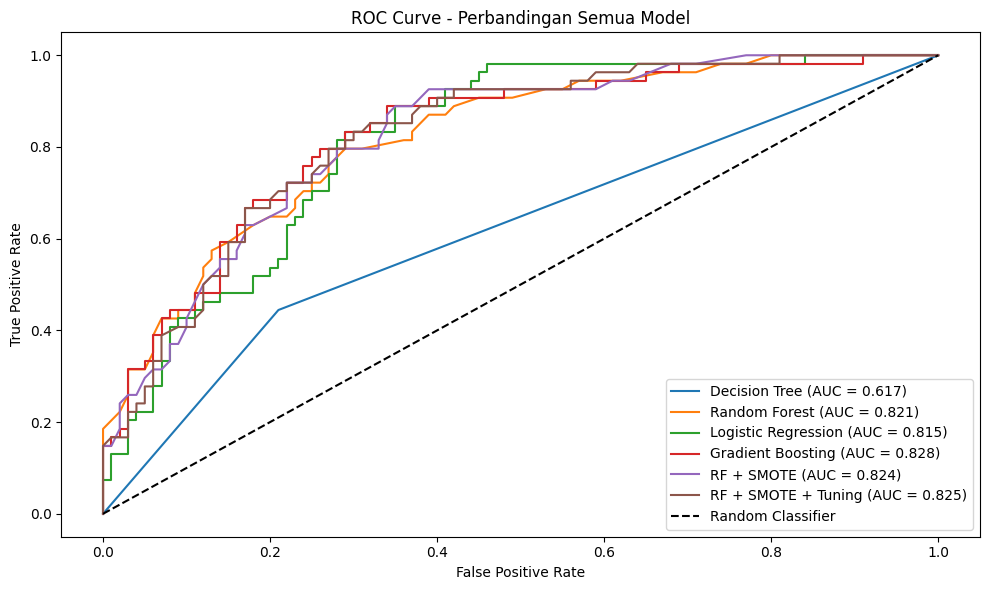

In [104]:
plt.figure(figsize=(10, 6))

roc_models = {
    'Decision Tree'         : dt_model,
    'Random Forest'         : rf_model,
    'Logistic Regression'   : lr_model,
    'Gradient Boosting'     : gb_model,
    'RF + SMOTE'            : rf_smote,
    'RF + SMOTE + Tuning'   : rf_tuned
}

for name, model in roc_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Perbandingan Semua Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

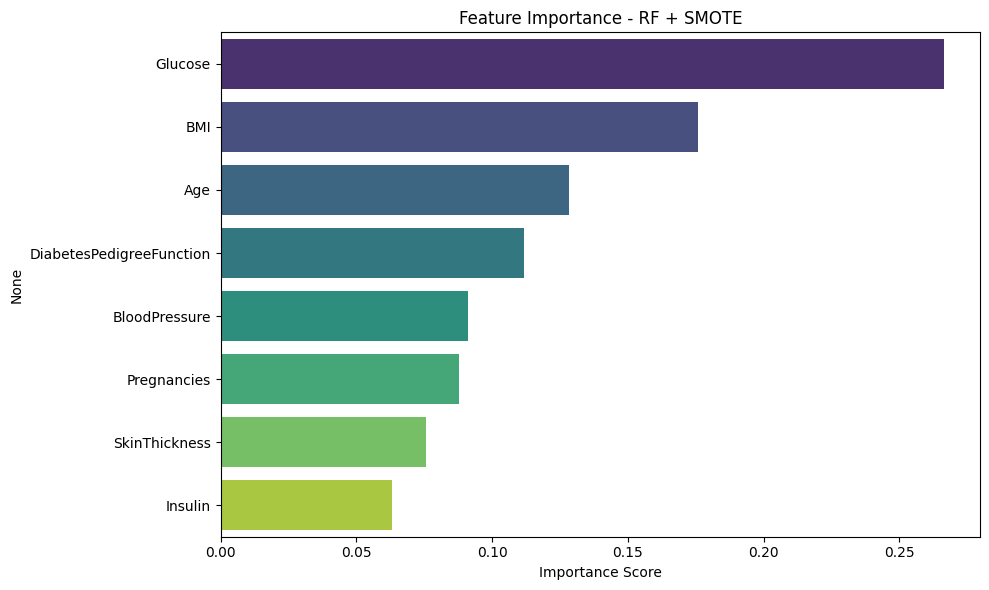

In [105]:
feat_importance = pd.Series(
    rf_smote.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title('Feature Importance - RF + SMOTE')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [109]:
# Cell 28 - Ringkasan Final + AUC Score
print("=" * 60)
print("RINGKASAN FINAL")
print("=" * 60)

final_models = {
    'Decision Tree'       : (dt_model, y_pred_dt),
    'Random Forest'       : (rf_model, y_pred_rf),
    'Logistic Regression' : (lr_model, y_pred_lr),
    'Gradient Boosting'   : (gb_model, y_pred_gb),
    'RF + SMOTE'          : (rf_smote, y_pred_rf_smote),
    'RF + SMOTE + Tuning' : (rf_tuned, y_pred_tuned)
}

for name, (model, y_pred) in final_models.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"{name}:")
    print(f"  Accuracy        : {report['accuracy']:.4f}")
    print(f"  Recall Diabetes : {report['1']['recall']:.4f}")
    print(f"  F1-Score        : {report['weighted avg']['f1-score']:.4f}")
    print(f"  AUC Score       : {auc:.4f}")
    print()

# Simpan model terbaik
joblib.dump(rf_tuned, 'best_model_diabetes.h5')
joblib.dump(scaler, 'scaler_diabetes.h5')
print("✅ Model terbaik berhasil disimpan!")

RINGKASAN FINAL
Decision Tree:
  Accuracy        : 0.6688
  Recall Diabetes : 0.4444
  F1-Score        : 0.6609
  AUC Score       : 0.6172

Random Forest:
  Accuracy        : 0.7597
  Recall Diabetes : 0.5926
  F1-Score        : 0.7555
  AUC Score       : 0.8209

Logistic Regression:
  Accuracy        : 0.7078
  Recall Diabetes : 0.5000
  F1-Score        : 0.7008
  AUC Score       : 0.8152

Gradient Boosting:
  Accuracy        : 0.7597
  Recall Diabetes : 0.5926
  F1-Score        : 0.7555
  AUC Score       : 0.8276

RF + SMOTE:
  Accuracy        : 0.7468
  Recall Diabetes : 0.7222
  F1-Score        : 0.7505
  AUC Score       : 0.8239

RF + SMOTE + Tuning:
  Accuracy        : 0.7597
  Recall Diabetes : 0.7222
  F1-Score        : 0.7627
  AUC Score       : 0.8255

✅ Model terbaik berhasil disimpan!


In [ ]:
joblib.dump(rf_smote, 'best_model_diabetes.h5')
joblib.dump(scaler, 'scaler_diabetes.h5')
print("✅ Model terbaik berhasil disimpan!")